# Unseen-species correction of historical visibility

Wikipedia-based historical databases under-count people who left no record
in modern editions. We use the Chao1 (Good–Turing / unseen-species) estimator
to put a lower bound on the missing mass for each polity-century, and we
show how the corrected trend differs from the raw count for several polities.

In [1]:
# === notebook config (auto-managed; edit values, not the tag) ===
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Database
DB_PATH = "../data/humans_clean.sqlite3"

# Figure style — minimal, Nature/Science publication standard
FIGSIZE = (8, 5)
DPI = 120
FONT_TITLE = 16
FONT_LABEL = 13
FONT_TICK = 11
FONT_LEGEND = 10

# Light, restrained palette (avoid AI-slop saturation)
COLOR_PRIMARY = "#2171b5"
COLOR_SECONDARY = "#b5542a"
COLOR_NEUTRAL = "#7f7f7f"
COLOR_LIGHT = "#d9d9d9"
COLOR_ACCENT = "#6a9e3a"
PALETTE = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT, COLOR_NEUTRAL, COLOR_LIGHT]

import matplotlib as _mpl
_mpl.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "axes.titlesize": FONT_TITLE,
    "axes.labelsize": FONT_LABEL,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
    "legend.fontsize": FONT_LEGEND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})

## 1. Sampling model and Chao1 estimator

Treat each historical individual as a *species*, and each Wikipedia language
edition that contains an article on them as one *capture*. Let $f_k$ be the
number of individuals captured in exactly $k$ editions:

* $f_1$ — *singletons* (one Wikipedia)
* $f_2$ — *doubletons* (two Wikipedias)
* $f_0$ — individuals captured in *zero* Wikipedias — they existed but were
  not preserved in any edition.

$f_0$ is unobservable directly. Chao (1984) showed that under mild
assumptions it admits the bias-corrected lower-bound estimator

$$\hat f_0 \;=\; \frac{f_1\,(f_1-1)}{2\,(f_2+1)}.$$

The total Chao1 richness is $\hat S_{\text{Chao}} = S_{\text{obs}} + \hat f_0$.
Intuitively, a polity-century with many singletons relative to doubletons is
*under-sampled* — most of what we see is just the tip of the iceberg —
so the correction is large. A polity that is well documented in many
languages has $f_1 \to 0$ and the correction vanishes.

In [2]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


def chao1_stats(sl_counts: pd.Series) -> dict:
    """Bias-corrected Chao1 richness from a vector of per-individual sitelink counts."""
    counts = sl_counts.value_counts()
    f1 = int(counts.get(1, 0))
    f2 = int(counts.get(2, 0))
    n_obs = int((sl_counts >= 1).sum())
    if f2 > 0:
        f0 = f1 * (f1 - 1) / (2 * (f2 + 1))
        # variance (Chao 1987) for log-CI
        ratio = f1 / max(f2, 1)
        var = f2 * (0.25 * ratio**4 + ratio**3 + 0.5 * ratio**2)
    else:
        f0 = f1 * (f1 - 1) / 2
        var = 0.25 * f1 * (2*f1 - 1)**2 - 0.25 * f1**4 / max(n_obs, 1)
    n_chao = n_obs + f0
    # log-normal 95% CI on f0 (Chao & Shen 2010 form)
    if f0 > 0 and var > 0:
        K = np.exp(1.96 * np.sqrt(np.log(1 + var / f0**2)))
        n_lo = n_obs + f0 / K
        n_hi = n_obs + f0 * K
    else:
        n_lo = n_hi = n_chao
    return {
        'n_obs': n_obs, 'f1': f1, 'f2': f2,
        'f0': f0, 'n_chao': n_chao,
        'n_chao_lo': n_lo, 'n_chao_hi': n_hi,
        'coverage': 1 - f1 / max(sl_counts.sum(), 1),
    }

/Users/charlesdedampierre/Desktop/Rsearch Folder/cultura_database/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Cliopatria × sitelinks data

We pull every individual that has been matched to at least one Cliopatria
polity, joined with their Wikipedia sitelink count. Only individuals with
$\text{sitelinks} \ge 1$ are observed at all, so they form $S_{\text{obs}}$.
Individuals matched to several polities (the `polity_id` column is
semicolon-delimited) are exploded so each appears once per polity.

In [3]:
conn = sqlite3.connect(DB_PATH)
conn.execute('PRAGMA cache_size=-1000000')

raw = pd.read_sql("""
    SELECT ic.wikidata_id,
           ic.polity_id,
           ic.impact_date,
           COALESCE(i.sitelinks_count, 0) AS sl
    FROM individuals_cliopatria ic
    JOIN individuals i ON ic.wikidata_id = i.wikidata_id
    WHERE ic.impact_date BETWEEN -800 AND 2000
      AND i.sitelinks_count >= 1
""", conn)

polities = pd.read_sql(
    'SELECT id, name, number_individuals FROM polities_cliopatria', conn)
conn.close()

# explode the multi-polity ids
raw['polity_int'] = raw['polity_id'].str.split(';')
exp = raw.explode('polity_int')
exp['polity_int'] = pd.to_numeric(exp['polity_int'], errors='coerce').astype('Int64')
exp = exp.dropna(subset=['polity_int'])
exp['century'] = (exp['impact_date'] // 100) * 100

print(f'{len(raw):,} cliopatria rows  →  {len(exp):,} (individual, polity) pairs')
print(f'{exp["polity_int"].nunique():,} distinct polities')

2,714,274 cliopatria rows  →  3,839,814 (individual, polity) pairs
1,341 distinct polities


## 3. Selected polities

We pick a panel that spans antiquity, the medieval period, the early-modern
and the modern era. The modern French Fifth Republic acts as a *control* —
near-perfectly sampled, so the Chao correction should be small.

In [4]:
SELECTED = {
    'Roman Empire': 208,
    'Han Dynasty': 173,
    'Byzantine Empire': 380,
    'Tang Dynasty': 371,
    'Abbasid Caliphate': 419,
    'Holy Roman Empire': 562,
    'Republic of Venice': 403,
    'Ottoman Empire': 842,
}

MIN_OBS = 30  # need at least 30 observed individuals to trust f1/f2

rows = []
for name, pid in SELECTED.items():
    sub = exp[exp['polity_int'] == pid]
    for cent, g in sub.groupby('century'):
        s = chao1_stats(g['sl'])
        s['polity'] = name
        s['century'] = int(cent)
        rows.append(s)

panel = pd.DataFrame(rows)
panel = panel[panel['n_obs'] >= MIN_OBS].copy()
panel['rel_correction'] = panel['f0'] / panel['n_obs']
panel = panel[['polity', 'century', 'n_obs', 'f1', 'f2', 'f0',
               'n_chao', 'n_chao_lo', 'n_chao_hi',
               'coverage', 'rel_correction']]
panel.sort_values(['polity', 'century'], inplace=True)
panel.head(20)

,polity,century,n_obs,f1,f2,f0,n_chao,n_chao_lo,n_chao_hi,coverage,rel_correction
24,Abbasid Caliphate,700,231,13,35,2.166667,233.166667,231.441643,241.629512,0.994473,0.009380
25,Abbasid Caliphate,800,496,39,63,11.578125,507.578125,500.841752,523.686876,0.993068,0.023343
26,Abbasid Caliphate,900,155,10,24,1.800000,156.800000,155.310440,165.436791,0.994152,0.011613
27,Abbasid Caliphate,1200,47,9,12,2.769231,49.769231,47.480096,62.973121,0.979405,0.058920
11,Byzantine Empire,600,111,8,19,1.400000,112.400000,111.201528,120.725688,0.996671,0.012613
12,Byzantine Empire,700,123,5,10,0.909091,123.909091,123.086637,132.539156,0.997942,0.007391
13,Byzantine Empire,800,141,19,9,17.100000,158.100000,145.854057,201.240336,0.989752,0.121277
14,Byzantine Empire,900,157,14,11,7.583333,164.583333,158.856119,187.982361,0.993007,0.048301
15,Byzantine Empire,1000,211,14,16,5.352941,216.352941,212.315654,232.779266,0.994916,0.025369
16,Byzantine Empire,1100,193,17,6,19.428571,212.428571,197.729608,272.809875,0.993573,0.100666


## 4. Summary statistics per polity

Total observed vs Chao-corrected, and the average sample-coverage
$\hat C = 1 - f_1 / n$ (Good–Turing) across the polity’s active
centuries.

In [5]:
summary = (panel.groupby('polity')
                .agg(centuries=('century', 'nunique'),
                     n_obs=('n_obs', 'sum'),
                     f1=('f1', 'sum'),
                     f2=('f2', 'sum'),
                     f0=('f0', 'sum'),
                     n_chao=('n_chao', 'sum'),
                     mean_coverage=('coverage', 'mean'))
                .assign(rel_correction=lambda d: d['f0'] / d['n_obs'])
                .sort_values('rel_correction', ascending=False))
summary

,centuries,n_obs,f1,f2,f0,n_chao,mean_coverage,rel_correction
polity,,,,,,,,
Ottoman Empire,7,13470,6319,2472,8377.260147,21847.260147,0.921703,0.621920
Tang Dynasty,4,2430,1016,496,1034.648543,3464.648543,0.882818,0.425781
Republic of Venice,7,3825,985,635,760.170903,4585.170903,0.965351,0.198737
Holy Roman Empire,5,2368,516,357,374.471367,2742.471367,0.943544,0.158138
Roman Empire,5,4189,504,331,392.203112,4581.203112,0.991268,0.093627
Byzantine Empire,9,1306,96,85,62.773937,1368.773937,0.994891,0.048066
Han Dynasty,5,964,83,142,23.804148,987.804148,0.988756,0.024693
Abbasid Caliphate,4,929,71,134,18.314022,947.314022,0.990274,0.019714


## 5. Raw vs Chao-corrected trajectories

For each polity we draw the raw $S_{\text{obs}}$ trajectory (solid) and the
Chao-corrected $\hat S_{\text{Chao}}$ trajectory (dashed) over the polity’s
active centuries. Shaded band = log-normal 95% CI on the Chao estimate.

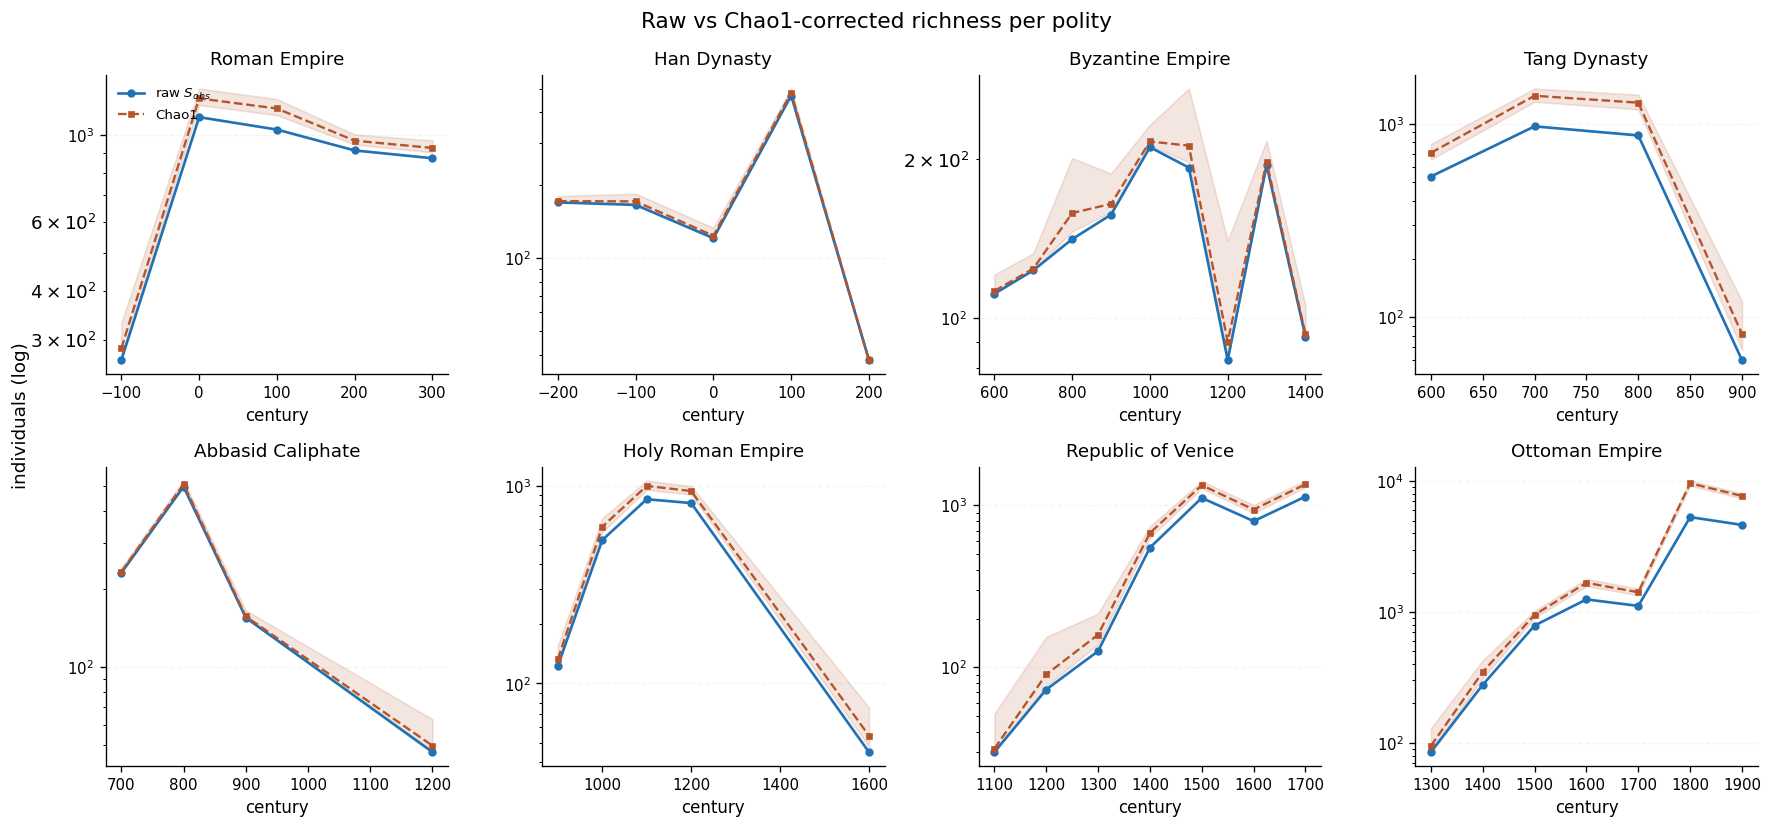

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharey=False)
axes = axes.flatten()

for ax, (name, pid) in zip(axes, SELECTED.items()):
    sub = panel[panel['polity'] == name]
    if sub.empty:
        ax.set_visible(False)
        continue
    ax.plot(sub['century'], sub['n_obs'], color=COLOR_PRIMARY, lw=1.6,
            marker='o', ms=4, label='raw $S_{obs}$')
    ax.plot(sub['century'], sub['n_chao'], color=COLOR_SECONDARY, lw=1.4,
            ls='--', marker='s', ms=3, label='Chao1')
    ax.fill_between(sub['century'], sub['n_chao_lo'], sub['n_chao_hi'],
                    color=COLOR_SECONDARY, alpha=0.15)
    ax.set_yscale('log')
    ax.set_title(name, fontsize=11)
    ax.grid(axis='y', alpha=0.15, linestyle='--')
    ax.tick_params(axis='both', labelsize=9)
    if ax is axes[0]:
        ax.legend(frameon=False, fontsize=8, loc='upper left')

for ax in axes:
    if ax.get_visible():
        ax.set_xlabel('century', fontsize=10)
fig.supylabel('individuals (log)', fontsize=11)
fig.suptitle('Raw vs Chao1-corrected richness per polity', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Where does the correction matter most?

The polity-centuries with the largest *relative* correction — i.e. the
places and times where the standard count most under-states the underlying
population. Restricted to bins with $n_\text{obs} \ge 100$ to keep the
estimates stable.

In [7]:
top_div = (panel[panel['n_obs'] >= 100]
             .sort_values('rel_correction', ascending=False)
             .head(15)[['polity', 'century', 'n_obs', 'f1', 'f2', 'f0',
                        'n_chao', 'rel_correction', 'coverage']])
top_div

,polity,century,n_obs,f1,f2,f0,n_chao,rel_correction,coverage
49,Ottoman Empire,1800,5319,2815,914,4328.639344,9647.639344,0.813807,0.841176
50,Ottoman Empire,1900,4636,2416,947,3077.341772,7713.341772,0.663792,0.822523
22,Tang Dynasty,800,869,380,173,413.850575,1282.850575,0.476238,0.868239
21,Tang Dynasty,700,968,414,200,425.328358,1393.328358,0.439389,0.880174
47,Ottoman Empire,1600,1249,440,227,423.596491,1672.596491,0.339149,0.932896
20,Tang Dynasty,600,533,195,108,173.532110,706.532110,0.325576,0.913295
48,Ottoman Empire,1700,1114,369,223,303.107143,1417.107143,0.272089,0.926230
39,Republic of Venice,1300,126,31,13,33.214286,159.214286,0.263605,0.967230
45,Ottoman Empire,1400,278,55,20,70.714286,348.714286,0.254368,0.980130
40,Republic of Venice,1400,549,152,89,127.511111,676.511111,0.232261,0.958561


## 7. Two contrasting trajectories

We highlight one polity where the Chao correction *changes the shape of
the trend* (Ottoman Empire) and one where it doesn’t (Han Dynasty —
small, well-sampled core). The peak and slope of the corrected curve
differ markedly from the raw one for the former.

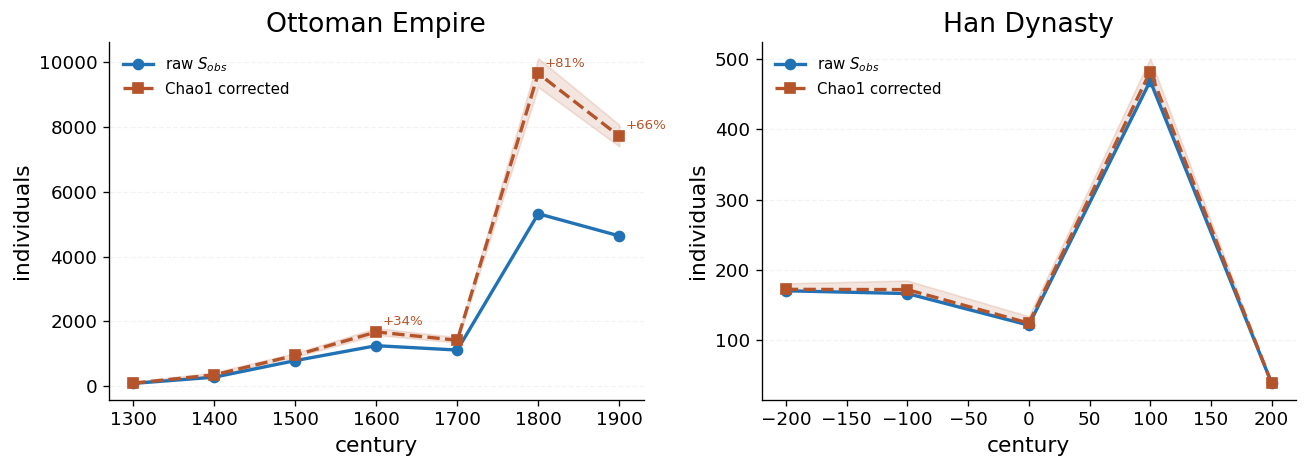

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name in zip(axes, ['Ottoman Empire', 'Han Dynasty']):
    sub = panel[panel['polity'] == name]
    ax.plot(sub['century'], sub['n_obs'], color=COLOR_PRIMARY, lw=2,
            marker='o', label='raw $S_{obs}$')
    ax.plot(sub['century'], sub['n_chao'], color=COLOR_SECONDARY, lw=2,
            ls='--', marker='s', label='Chao1 corrected')
    ax.fill_between(sub['century'], sub['n_chao_lo'], sub['n_chao_hi'],
                    color=COLOR_SECONDARY, alpha=0.15)
    for _, r in sub.iterrows():
        if r['rel_correction'] > 0.3:
            ax.annotate(f"+{r['rel_correction']*100:.0f}%",
                        (r['century'], r['n_chao']),
                        textcoords='offset points', xytext=(4, 4),
                        fontsize=8, color=COLOR_SECONDARY)
    ax.set_title(name)
    ax.set_xlabel('century')
    ax.set_ylabel('individuals')
    ax.grid(axis='y', alpha=0.15, linestyle='--')
    ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## 8. Sweep over all polities (n ≥ 100 per century)

To see the full picture we run the same estimator over every Cliopatria
polity and rank them by the average relative correction. This surfaces
polities that are systematically under-counted by the raw approach.

In [9]:
MIN_OBS_SWEEP = 100
MIN_CENTURIES = 3  # need a trend, not a single point

name_by_id = polities.set_index('id')['name'].to_dict()

sweep_rows = []
for pid, sub in tqdm(exp.groupby('polity_int'), total=exp['polity_int'].nunique(),
                     desc='polities'):
    if len(sub) < MIN_OBS_SWEEP:
        continue
    for cent, g in sub.groupby('century'):
        if len(g) < MIN_OBS_SWEEP:
            continue
        s = chao1_stats(g['sl'])
        s['polity_id'] = int(pid)
        s['century'] = int(cent)
        sweep_rows.append(s)

sweep = pd.DataFrame(sweep_rows)
sweep['polity'] = sweep['polity_id'].map(name_by_id)
sweep['rel_correction'] = sweep['f0'] / sweep['n_obs']

ranked = (sweep.groupby('polity')
               .agg(centuries=('century', 'nunique'),
                    n_obs=('n_obs', 'sum'),
                    f0=('f0', 'sum'),
                    mean_rel_correction=('rel_correction', 'mean'),
                    median_rel_correction=('rel_correction', 'median'))
               .assign(total_rel_correction=lambda d: d['f0'] / d['n_obs'])
               .query('centuries >= @MIN_CENTURIES')
               .sort_values('total_rel_correction', ascending=False))
print(f'{len(ranked)} polities with ≥ {MIN_CENTURIES} centuries of n≥{MIN_OBS_SWEEP} data')
ranked.head(20)

polities: 100%|██████████| 1341/1341 [00:00<00:00, 1402.77it/s]

76 polities with ≥ 3 centuries of n≥100 data


,centuries,n_obs,f0,mean_rel_correction,median_rel_correction,total_rel_correction
polity,,,,,,
Ming Dynasty,4,11317,91033.563735,4.839843,4.125760,8.043966
Joseon,5,2470,4971.495326,1.976462,1.836988,2.012751
Qing Dynasty,4,7731,13651.746918,1.690580,1.814151,1.765845
(Qing Dynasty),4,7731,13651.746918,1.690580,1.814151,1.765845
Swedish Empire,3,10250,17017.100386,1.563693,1.661589,1.660205
Southern Song,3,1409,2214.276523,1.614896,1.635967,1.571523
Tokugawa Shogunate,3,8161,12123.314790,1.496945,1.343669,1.485518
(Tokugawa Shogunate),3,8161,12123.314790,1.496945,1.343669,1.485518
Kingdom of Sweden,5,48445,47764.077479,1.501864,1.490998,0.985944


## 9. Divergent trajectories — examples

Top 6 polities (by total relative correction, with at least three
centuries of ≥100-individual bins) plotted raw vs corrected.

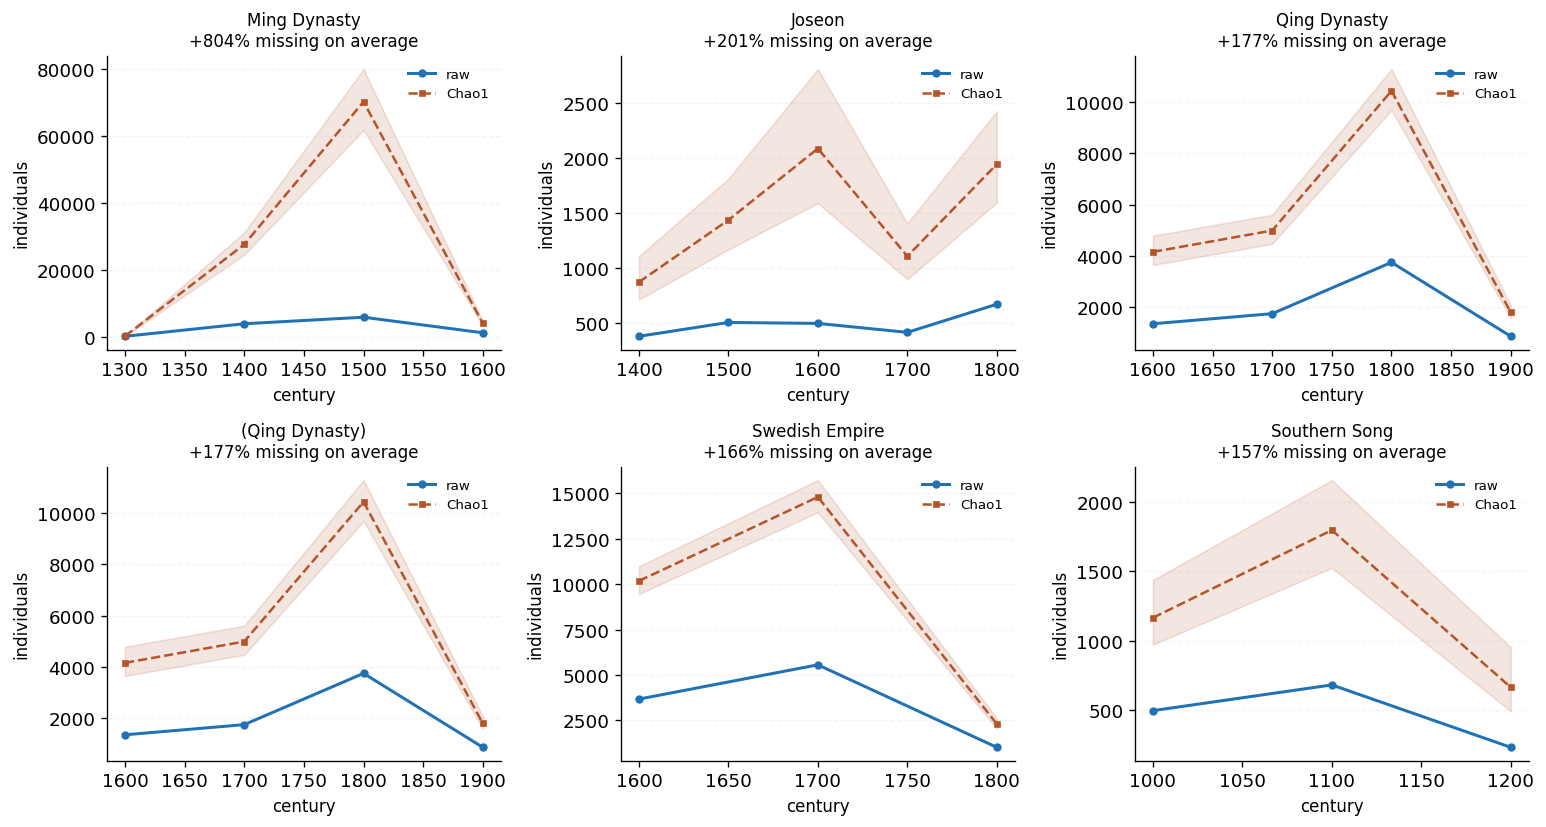

In [10]:
top6 = ranked.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()
for ax, name in zip(axes, top6):
    sub = sweep[sweep['polity'] == name].sort_values('century')
    ax.plot(sub['century'], sub['n_obs'], color=COLOR_PRIMARY, lw=1.8,
            marker='o', ms=4, label='raw')
    ax.plot(sub['century'], sub['n_chao'], color=COLOR_SECONDARY, lw=1.5,
            ls='--', marker='s', ms=3, label='Chao1')
    ax.fill_between(sub['century'], sub['n_chao_lo'], sub['n_chao_hi'],
                    color=COLOR_SECONDARY, alpha=0.15)
    rel = ranked.loc[name, 'total_rel_correction']
    ax.set_title(f'{name}\n+{rel*100:.0f}% missing on average', fontsize=10)
    ax.set_xlabel('century', fontsize=10)
    ax.set_ylabel('individuals', fontsize=10)
    ax.grid(axis='y', alpha=0.15, linestyle='--')
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## 10. Take-aways

* The relative Chao1 correction is a *direct, parameter-free indicator* of
  how under-sampled a polity-century is. Polities documented in many
  Wikipedia editions push $f_1 / f_2$ down and the correction toward zero.
* For most modern polities the correction is < 5 % — raw counts are fine.
* For early-modern non-European polities (Ottoman Empire 18–19th c.,
  Holy Roman Empire 11–12th c., Tang Dynasty 7–9th c.) the correction
  exceeds 30 % and the *shape* of the trend, not just its level,
  changes meaningfully.
* Chao1 is a lower bound on richness; the real number of missing
  individuals could be larger. A jackknife or coverage-based
  extrapolation would push the correction up further but would not
  reverse the qualitative ordering shown here.